In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("likithagedipudi/starbucks-customer-ordering-patterns")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'starbucks-customer-ordering-patterns' dataset.
Path to dataset files: /kaggle/input/starbucks-customer-ordering-patterns


In [ ]:
import pandas as pd
import os

print(os.listdir(path))

['starbucks_customer_ordering_patterns.csv']


In [ ]:
df = pd.read_csv(path + "/starbucks_customer_ordering_patterns.csv")

In [ ]:
df.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


In [ ]:
# 변수별 데이터 타입 확인 및 결손 값 개수 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-nul

In [ ]:
# 결측치 없는 거 확실하게 확인하기
df.isna().sum()

,0
customer_id,0
order_id,0
order_date,0
order_time,0
day_of_week,0
order_channel,0
store_id,0
store_location_type,0
region,0
customer_age_group,0


In [ ]:
# isnull 함수 사용시 True/False로 눈으로 확인 가능함 (null이면 True로 표현됨)
df.isnull()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# "총 판매금액" 기초 통계
df["total_spend"].describe()

# 평균값(mean) 보다 중앙값(50%)를 더 중요하게 보기
# 평균값은 극단값에 영향을 받지만 중앙값은 받지않음

,total_spend
count,100000.000000
mean,14.866771
std,5.506800
min,3.510000
25%,10.837500
50%,14.170000
75%,18.180000
max,40.310000


<Axes: >

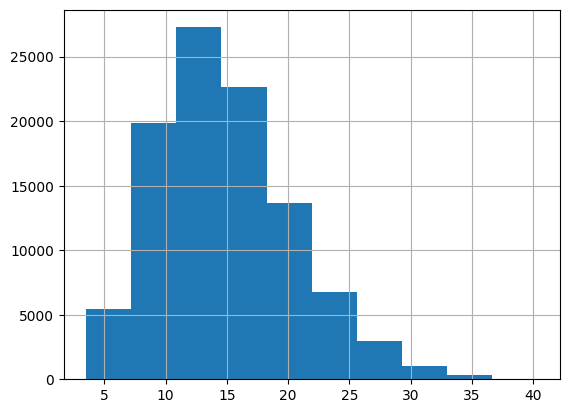

In [ ]:
# 판매량에 대한 분포도 확인
df["total_spend"].hist()

# 이상치 값을 대략 눈으로 확인함

In [ ]:
# 이상치 객관적 확인 IQR
"""
1.5 * IQR(Q3 - Q1)
"""
Q1 = df['total_spend'].quantile(0.25)
Q3 = df['total_spend'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치가 몇 개인지 확인
outliers = df[(df['total_spend'] < lower) | (df['total_spend'] > upper)]
print(f"lower: {lower:.2f}, upper: {upper:.2f}")
print(f"이상치 개수: {len(outliers)}")

lower: -0.18, upper: 29.19
이상치 개수: 1415


In [ ]:
# 정상 범위 데이터만 남기기
df_cleaned = df[(df['total_spend'] >= lower) & (df['total_spend'] <= upper)]

print(f"원본 행 수 : {len(df)}")
print(f"제거후 행 수 : {len(df_cleaned)}")

원본 행 수 : 100000
제거후 행 수 : 98585


In [ ]:
import pandas as pd

# df_cleaned는 sHUeOQyEORLV에서 customer_stats가 merge된 상태

# 1. 문자열을 숫자로 바꾸기 위한 원핫 인코딩
df_final = pd.get_dummies(df_cleaned, columns = [
    'day_of_week',
    'order_channel',
    'store_location_type',
    'region',
    'customer_age_group',
    'customer_gender',
    'drink_category'], drop_first = True)

# 2. 문자열 값인 order_time을 숫자 형으로 변환 (order_time 컬럼이 존재하는 경우에만)
if 'order_time' in df_final.columns:
    df_final['order_hour'] = pd.to_datetime(df_final['order_time'], format='%H:%M').dt.hour
    df_final['order_minute'] = pd.to_datetime(df_final['order_time'], format='%H:%M').dt.minute
    df_final = df_final.drop(columns=['order_time'])

# 3. 모델 학습에 불필요한 식별자 컬럼 제거
id_cols_to_drop = ['customer_id', 'order_id', 'order_date', 'store_id']
df_final = df_final.drop(columns=[col for col in id_cols_to_drop if col in df_final.columns])

# corr()을 통해서 x와 y간의 상관관계 확인하기
corr = df_final.corr(numeric_only = True)["total_spend"].sort_values(ascending=False)
print(corr)
display(df_final.head())

total_spend                          1.000000
cart_size                            0.887672
order_channel_Mobile App             0.491512
num_customizations                   0.395857
order_ahead                          0.374397
has_food_item                        0.208318
is_rewards_member                    0.146067
customer_age_group_25-34             0.079340
customer_satisfaction                0.063871
avg_satisfaction_y                   0.033575
avg_satisfaction_x                   0.033575
day_of_week_Sat                      0.007957
region_West                          0.005830
customer_gender_Prefer not to say    0.004625
drink_category_Tea                   0.003187
region_Southwest                     0.003111
store_location_type_Suburban         0.002568
customer_gender_Non-binary           0.001992
order_hour                           0.001846
region_Southeast                     0.001795
drink_category_Frappuccino           0.001756
day_of_week_Thu                   

,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,has_food_item,order_ahead,customer_satisfaction,total_orders_x,avg_satisfaction_x,...,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea,order_hour,order_minute
0,False,5,0,14.48,8.2,False,False,4,8,4.125000,...,True,False,False,False,False,False,True,False,8,47
1,True,1,3,9.52,5.4,False,True,4,6,3.000000,...,False,False,False,False,False,False,False,False,8,2
2,False,2,1,9.32,4.9,False,False,5,4,3.000000,...,False,False,False,False,False,False,False,False,5,40
3,True,2,1,9.55,3.5,False,False,4,7,3.714286,...,False,False,False,False,False,False,True,False,15,10
4,False,3,1,12.24,4.1,False,False,3,2,3.000000,...,False,False,False,False,True,False,False,False,7,38


In [ ]:
df_cleaned.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,...,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction,total_orders,avg_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,...,5,0,14.48,8.2,Refresher,False,False,4,8,4.125000
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,...,1,3,9.52,5.4,Brewed Coffee,False,True,4,6,3.000000
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,...,2,1,9.32,4.9,Brewed Coffee,False,False,5,4,3.000000
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,...,2,1,9.55,3.5,Refresher,False,False,4,7,3.714286
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,...,3,1,12.24,4.1,Frappuccino,False,False,3,2,3.000000


In [ ]:
# 새로운 독립변수 1개 만들어보기
#고객별(customer_id) '주문 횟수'와 '평균 만족도' 계산하기
customer_stats = df_cleaned.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),               # 주문 횟수 카운트
    avg_satisfaction=('customer_satisfaction', 'mean') # 만족도 평균
).reset_index()

df_cleaned = df_cleaned.merge(customer_stats, on='customer_id', how='left')

In [ ]:
df.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


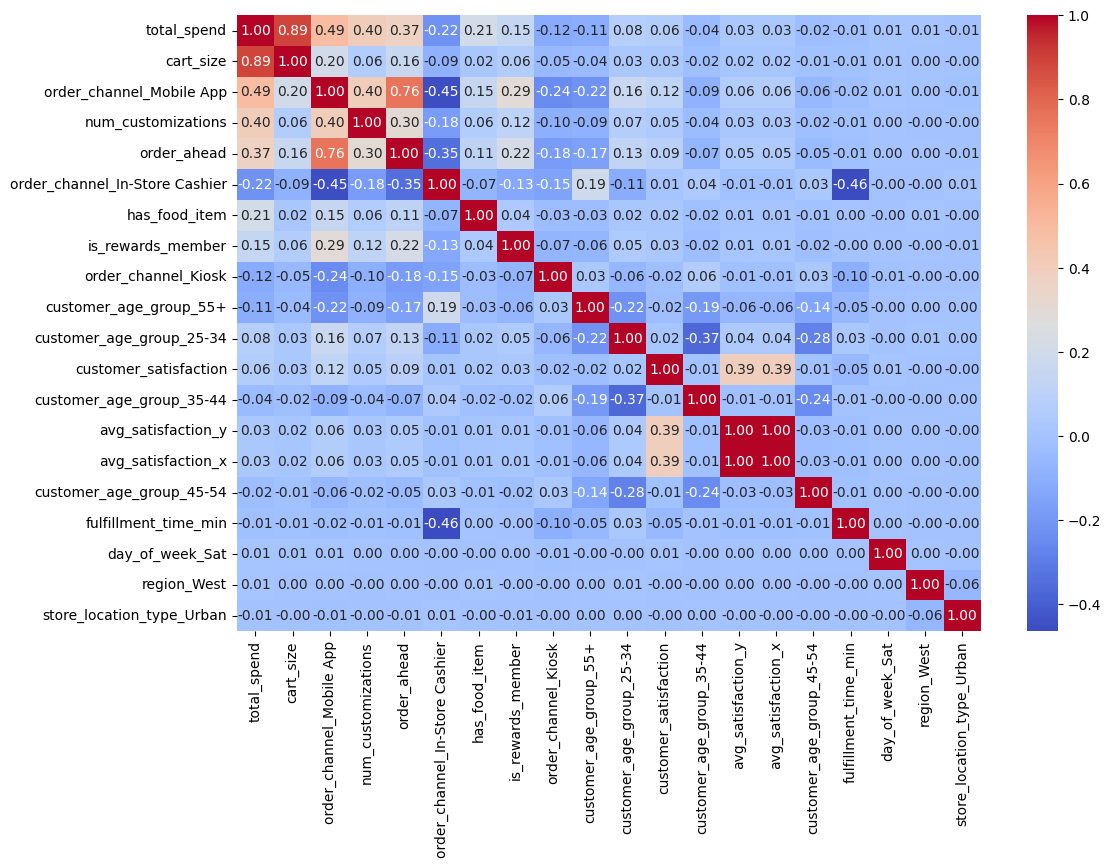

In [ ]:
# 히트맵을 통해 독립변수 & 종속변수 상관관계 시각화

import matplotlib.pyplot as plt
import seaborn as sns

top_cols = corr.abs().sort_values(ascending=False).head(20).index.tolist() # 상위 15개만 사용
plt.figure(figsize=(12,8)) # 그래프 크기 지정
sns.heatmap(
    df_final[top_cols].corr(),
    annot = True, # 각 칸에 숫자 표시
    fmt = '.2f',
    cmap = 'coolwarm' # 파랑(음의 상관) ~ 빨강(양의 상관) 색상
)

plt.show()

In [ ]:
# 독립 변수(X) / 종속 변수(Y) 선정
# 이유: 우리가 예측할 정답(Y)은 '총 지출액(total_spend)'이고, 나머지 조건(X)들을 보고 맞출 것임
Y = df_final["total_spend"]
X = df_final.drop(["total_spend"], axis=1)

In [ ]:
df_final.head()

,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,has_food_item,order_ahead,customer_satisfaction,total_orders_x,avg_satisfaction_x,...,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea,order_hour,order_minute
0,False,5,0,14.48,8.2,False,False,4,8,4.125000,...,True,False,False,False,False,False,True,False,8,47
1,True,1,3,9.52,5.4,False,True,4,6,3.000000,...,False,False,False,False,False,False,False,False,8,2
2,False,2,1,9.32,4.9,False,False,5,4,3.000000,...,False,False,False,False,False,False,False,False,5,40
3,True,2,1,9.55,3.5,False,False,4,7,3.714286,...,False,False,False,False,False,False,True,False,15,10
4,False,3,1,12.24,4.1,False,False,3,2,3.000000,...,False,False,False,False,True,False,False,False,7,38


In [ ]:
# 데이터 전처리 후 새로운 데이터프레임으로 저장
df_final.to_csv("starbucks_preprocessed.csv", index=False)

In [ ]:
df_loaded = pd.read_csv("starbucks_preprocessed.csv") #데이터 프레임 불러오기
df_loaded

,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,has_food_item,order_ahead,customer_satisfaction,total_orders_x,avg_satisfaction_x,...,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea,order_hour,order_minute
0,False,5,0,14.48,8.2,False,False,4,8,4.125000,...,True,False,False,False,False,False,True,False,8,47
1,True,1,3,9.52,5.4,False,True,4,6,3.000000,...,False,False,False,False,False,False,False,False,8,2
2,False,2,1,9.32,4.9,False,False,5,4,3.000000,...,False,False,False,False,False,False,False,False,5,40
3,True,2,1,9.55,3.5,False,False,4,7,3.714286,...,False,False,False,False,False,False,True,False,15,10
4,False,3,1,12.24,4.1,False,False,3,2,3.000000,...,False,False,False,False,True,False,False,False,7,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98580,True,4,0,15.18,3.2,False,True,4,8,4.000000,...,False,True,False,False,True,False,False,False,17,8
98581,True,5,2,16.71,5.5,False,False,3,8,3.500000,...,False,False,True,True,False,False,False,False,8,7
98582,False,3,0,9.12,3.3,False,False,1,9,3.666667,...,False,False,False,True,False,False,False,False,16,5
98583,True,5,1,18.02,1.9,False,False,2,10,3.900000,...,False,False,False,False,False,True,False,False,18,32


In [ ]:
# # 문자열 값인 order_time을 숫자 형으로 변환
# # order_time을 hour, minute로 쪼개어 변환

# import pandas as pd

# # %H:%M으로 형식지정
# X['order_hour'] = pd.to_datetime(X['order_time'], format='%H:%M').dt.hour
# X['order_minute'] = pd.to_datetime(X['order_time'], format='%H:%M').dt.minute
# X = X.drop(columns=['order_time'])

# df_final = pd.DataFrame(X)
# df_final.head()

In [ ]:
# 전처리 및 변수 선택이 완료된 df_final을 새로운 CSV 파일로 저장
df_final.to_csv("starbucks_preprocessed_selected_features.csv", index=False)
print("Features selected and preprocessed data saved to 'starbucks_preprocessed_selected_features.csv'")

df_final.head()

Features selected and preprocessed data saved to 'starbucks_preprocessed_selected_features.csv'


,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,has_food_item,order_ahead,customer_satisfaction,total_orders_x,avg_satisfaction_x,...,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea,order_hour,order_minute
0,False,5,0,14.48,8.2,False,False,4,8,4.125000,...,True,False,False,False,False,False,True,False,8,47
1,True,1,3,9.52,5.4,False,True,4,6,3.000000,...,False,False,False,False,False,False,False,False,8,2
2,False,2,1,9.32,4.9,False,False,5,4,3.000000,...,False,False,False,False,False,False,False,False,5,40
3,True,2,1,9.55,3.5,False,False,4,7,3.714286,...,False,False,False,False,False,False,True,False,15,10
4,False,3,1,12.24,4.1,False,False,3,2,3.000000,...,False,False,False,False,True,False,False,False,7,38


In [ ]:
df_loaded = pd.read_csv("starbucks_preprocessed_selected_features.csv") #데이터 프레임 불러오기
df_loaded

,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,has_food_item,order_ahead,customer_satisfaction,total_orders_x,avg_satisfaction_x,...,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea,order_hour,order_minute
0,False,5,0,14.48,8.2,False,False,4,8,4.125000,...,True,False,False,False,False,False,True,False,8,47
1,True,1,3,9.52,5.4,False,True,4,6,3.000000,...,False,False,False,False,False,False,False,False,8,2
2,False,2,1,9.32,4.9,False,False,5,4,3.000000,...,False,False,False,False,False,False,False,False,5,40
3,True,2,1,9.55,3.5,False,False,4,7,3.714286,...,False,False,False,False,False,False,True,False,15,10
4,False,3,1,12.24,4.1,False,False,3,2,3.000000,...,False,False,False,False,True,False,False,False,7,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98580,True,4,0,15.18,3.2,False,True,4,8,4.000000,...,False,True,False,False,True,False,False,False,17,8
98581,True,5,2,16.71,5.5,False,False,3,8,3.500000,...,False,False,True,True,False,False,False,False,8,7
98582,False,3,0,9.12,3.3,False,False,1,9,3.666667,...,False,False,False,True,False,False,False,False,16,5
98583,True,5,1,18.02,1.9,False,False,2,10,3.900000,...,False,False,False,False,False,True,False,False,18,32


In [ ]:
import pandas as pd

# Ensure df_loaded is used for processing order_time
# Make a copy to avoid modifying the original df_loaded if it's used elsewhere
df_processed = df_loaded.copy()

# Assuming df_loaded from the CSV already has order_hour/minute and no order_time
# If 'order_time' column is still present, process it.
if 'order_time' in df_processed.columns:
    df_processed['order_hour'] = pd.to_datetime(df_processed['order_time'], format='%H:%M').dt.hour
    df_processed['order_minute'] = pd.to_datetime(df_processed['order_time'], format='%H:%M').dt.minute
    df_processed = df_processed.drop(columns=['order_time'])

# Redefine X and Y based on the processed dataframe
Y = df_processed["total_spend"]
X = df_processed.drop(columns=["total_spend"])

display(X.head())

,is_rewards_member,cart_size,num_customizations,fulfillment_time_min,has_food_item,order_ahead,customer_satisfaction,total_orders_x,avg_satisfaction_x,total_orders_y,...,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea,order_hour,order_minute
0,False,5,0,8.2,False,False,4,8,4.125000,8,...,True,False,False,False,False,False,True,False,8,47
1,True,1,3,5.4,False,True,4,6,3.000000,6,...,False,False,False,False,False,False,False,False,8,2
2,False,2,1,4.9,False,False,5,4,3.000000,4,...,False,False,False,False,False,False,False,False,5,40
3,True,2,1,3.5,False,False,4,7,3.714286,7,...,False,False,False,False,False,False,True,False,15,10
4,False,3,1,4.1,False,False,3,2,3.000000,2,...,False,False,False,False,True,False,False,False,7,38


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# 테스트 데이터 20%로 설정, X, Y를 토대로 훈련 데이터, 테스트 데이터 생성

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train, X_test)
print(Y_train, Y_test)

       is_rewards_member  cart_size  num_customizations  fulfillment_time_min  \
70059               True          1                   1                   3.8   
69797              False          2                   2                   2.5   
45795              False          2                   4                   4.2   
86558              False          1                   0                   2.5   
74273               True          2                   1                   3.9   
...                  ...        ...                 ...                   ...   
6265                True          3                   0                   7.3   
54886              False          2                   0                   2.8   
76820              False          6                   4                   3.3   
860                False          2                   1                   2.3   
15795               True          1                   0                   5.1   

       has_food_item  order

In [ ]:
scale_cols = ['cart_size', 'num_customizations', 'fulfillment_time_min', 'customer_satisfaction']

scaler = StandardScaler() # 평균0, 표준편차 1인 값으로 표준화 실행
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols]) # test는 fit 없음

# 스케일링 진행 후 넘파이로 된 것 ->DataFrame만들어주기
df_scale = pd.DataFrame(X_train[scale_cols], columns=scale_cols)

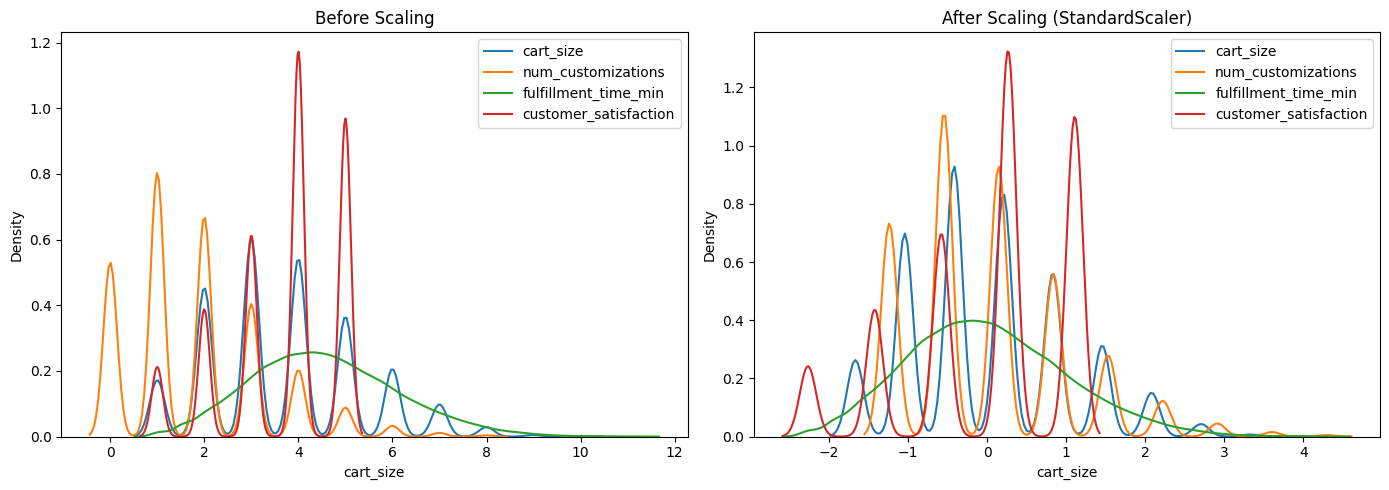

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# scaling 후 표준화 시각화하기
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 원본 데이터(df_cleaned)에서 스케일링 대상 컬럼들의 분포 (order_hour, order_minute 포함)
ax1.set_title('Before Scaling')
# X 에는 이미 order_hour 등이 생성되어 있으므로 X_train의 원본 스케일을 활용하기 위해 scaler 적용 전 값 활용
for col in scale_cols:
    sns.kdeplot(X[col], ax=ax1, label=col)
ax1.legend()

ax2.set_title('After Scaling (StandardScaler)')
for col in scale_cols:
    sns.kdeplot(X_train[col], ax=ax2, label=col)
ax2.legend()

plt.tight_layout()
plt.show()

LinearRegression fit() & predict()

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f'기본 MSE: {mse:.4f}')
print(f'기본 R²:  {r2:.4f}')

기본 MSE: 0.9356
기본 R²:  0.9652


In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 회귀는 R²로 비교 (1에 가까울수록 좋음)
kfold_r2 = cross_val_score(lr, X_train, Y_train, cv=kfold, scoring='r2')
# MSE는 음수로 반환되므로 부호 반전
kfold_mse = -cross_val_score(lr, X_train, Y_train, cv=kfold, scoring='neg_mean_squared_error')

print(f'KFold R² 각 폴드: {kfold_r2}')
print(f'KFold R² 평균:    {kfold_r2.mean():.4f}')
print(f'KFold MSE 각 폴드: {kfold_mse}')
print(f'KFold MSE 평균:    {kfold_mse.mean():.4f}')

print('\n===== 정확도 비교 =====')
print(f'기본 R²:       {r2:.4f}')
print(f'KFold R² 평균: {kfold_r2.mean():.4f}')
print(f'기본 MSE:       {mse:.4f}')
print(f'KFold MSE 평균: {kfold_mse.mean():.4f}')

KFold R² 각 폴드: [0.96432213 0.96507941 0.96468581 0.96459341 0.96442205]
KFold R² 평균:    0.9646
KFold MSE 각 폴드: [0.93836543 0.92857433 0.93671718 0.94241592 0.93381165]
KFold MSE 평균:    0.9360

===== 정확도 비교 =====
기본 R²:       0.9652
KFold R² 평균: 0.9646
기본 MSE:       0.9356
KFold MSE 평균: 0.9360


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# 하이퍼파라터 설정
param_grid = {
    'fit_intercept': [True, False], # 절편 포함 여부
    'positive': [True, False] # 계수를 양수로만 제한할지
}

grid_search = GridSearchCV(
    estimator = LinearRegression(),
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

grid_search.fit(X_train, Y_train)

print(f"최적 파라미터: {grid_search.best_params_}")
print(f"GridSearch 최적 R제곱: {grid_search.best_score_}")

Y_pred_grid = grid_search.best_estimator_.predict(X_test)

print(f'기본 LinearRegression R²: {r2:.4f}')
print(f'KFold R² 평균:            {kfold_r2.mean():.4f}')
print(f'GridSearchCV 최적 R²:     {r2_score(Y_test, Y_pred_grid):.4f}')

최적 파라미터: {'fit_intercept': True, 'positive': True}
GridSearch 최적 R제곱: 0.9646198802069774
기본 LinearRegression R²: 0.9652
KFold R² 평균:            0.9646
GridSearchCV 최적 R²:     0.9652


**회귀 데이터 성능 지표 확인:**

In [ ]:

from sklearn.metrics import mean_absolute_error

mae  = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)  # mse는 위 셀에서

print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')


MAE  : 0.8219
MSE  : 0.9356
RMSE : 0.9673
R²   : 0.9652


이상치 테스트

In [ ]:
import numpy as np

Y_test_outlier = Y_test.copy()

# 앞 5개 값을 극단적으로 바꿈 (이상치 시뮬레이션)
outlier_indices = Y_test_outlier.index[:5]
Y_test_outlier[outlier_indices] = Y_test_outlier[outlier_indices] * 10

mae_out  = mean_absolute_error(Y_test_outlier, Y_pred)
mse_out  = mean_squared_error(Y_test_outlier, Y_pred)
rmse_out = np.sqrt(mse_out)
r2_out   = r2_score(Y_test_outlier, Y_pred)

print("[ 이상치 제거 후 ]  MAE:{:.2f}  MSE:{:.2f}  RMSE:{:.2f}  R²:{:.4f}".format(mae, mse, rmse, r2))
print("[ 이상치 포함    ]  MAE:{:.2f}  MSE:{:.2f}  RMSE:{:.2f}  R²:{:.4f}".format(mae_out, mse_out, rmse_out, r2_out))
print()
print(f"→ RMSE 변화: {rmse:.2f} → {rmse_out:.2f}  (이상치에 훨씬 민감)")
print(f"→ MAE  변화: {mae:.2f} → {mae_out:.2f}   (상대적으로 덜 민감)")
print(f"→ R²   변화: {r2:.4f} → {r2_out:.4f}  (설명력 급락)")

[ 이상치 제거 후 ]  MAE:0.82  MSE:0.94  RMSE:0.97  R²:0.9652
[ 이상치 포함    ]  MAE:0.85  MSE:3.56  RMSE:1.89  R²:0.8789

→ RMSE 변화: 0.97 → 1.89  (이상치에 훨씬 민감)
→ MAE  변화: 0.82 → 0.85   (상대적으로 덜 민감)
→ R²   변화: 0.9652 → 0.8789  (설명력 급락)


추천 조합: RMSE + MAE + R²

1) RMSE(0.97) ≈ MAE(0.82)  →  오차가 고르게 분포됨 (이상치 없음)
   RMSE(1.89) ≫ MAE(0.85)  →  이상치 존재 신호

2) R² = 0.9652  →  모델이 데이터의 96.5%를 설명 (좋은 모델)
   이상치 주입 시 0.8789로 급락

3) MSE는 0.94 → 3.56으로 가장 크게 튀지만 단위 해석이 어려움
   보고 시엔 RMSE 사용 권장

### 중복 데이터 확인 및 제거

In [ ]:
duplicate_rows = df_cleaned.duplicated().sum()
print(f"중복 데이터 개수: {duplicate_rows}")

if duplicate_rows > 0:
    df_cleaned_no_duplicates = df_cleaned.drop_duplicates()
    print(f"중복 제거 후 데이터 개수: {len(df_cleaned_no_duplicates)}")
else:
    df_cleaned_no_duplicates = df_cleaned
    print("중복 데이터가 없습니다.")

df_cleaned = df_cleaned_no_duplicates.copy()

중복 데이터 개수: 0
중복 데이터가 없습니다.


목표값 total_spend 치우침 대응

치우침 대응전, total_spend와 다른 변수와의 범위 차이 확인하기

In [ ]:
X_train.head() # X_train (스케일링 변수 + 문자형 변수)

,is_rewards_member,cart_size,num_customizations,fulfillment_time_min,has_food_item,order_ahead,customer_satisfaction,total_orders_x,avg_satisfaction_x,total_orders_y,...,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea,order_hour,order_minute
70059,True,-1.666737,-0.545311,-0.478321,False,True,-0.578659,10,3.800000,10,...,False,False,False,False,False,False,False,False,11,19
69797,False,-1.042205,0.146174,-1.313453,False,False,0.265046,9,3.888889,9,...,False,False,False,False,False,False,True,False,6,53
45795,False,-1.042205,1.529143,-0.221357,False,True,-1.422365,5,3.600000,5,...,True,False,False,False,True,False,False,False,10,40
86558,False,-1.666737,-1.236796,-1.313453,True,False,-1.422365,6,3.166667,6,...,True,False,False,False,False,False,False,False,19,53
74273,True,-1.042205,-0.545311,-0.414080,False,True,1.108751,10,3.600000,10,...,False,False,False,True,False,False,False,False,15,23


In [ ]:
df_scale.head() # 현재 df 내부(스케일링된 변수만)

,cart_size,num_customizations,fulfillment_time_min,customer_satisfaction
70059,-1.666737,-0.545311,-0.478321,-0.578659
69797,-1.042205,0.146174,-1.313453,0.265046
45795,-1.042205,1.529143,-0.221357,-1.422365
86558,-1.666737,-1.236796,-1.313453,-1.422365
74273,-1.042205,-0.545311,-0.414080,1.108751


In [ ]:
Y_train.head()

,total_spend
70059,5.22
69797,8.54
45795,13.55
86558,6.40
74273,7.95


In [ ]:
!pip install Fkoreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.1 MB/s eta 0:00:00


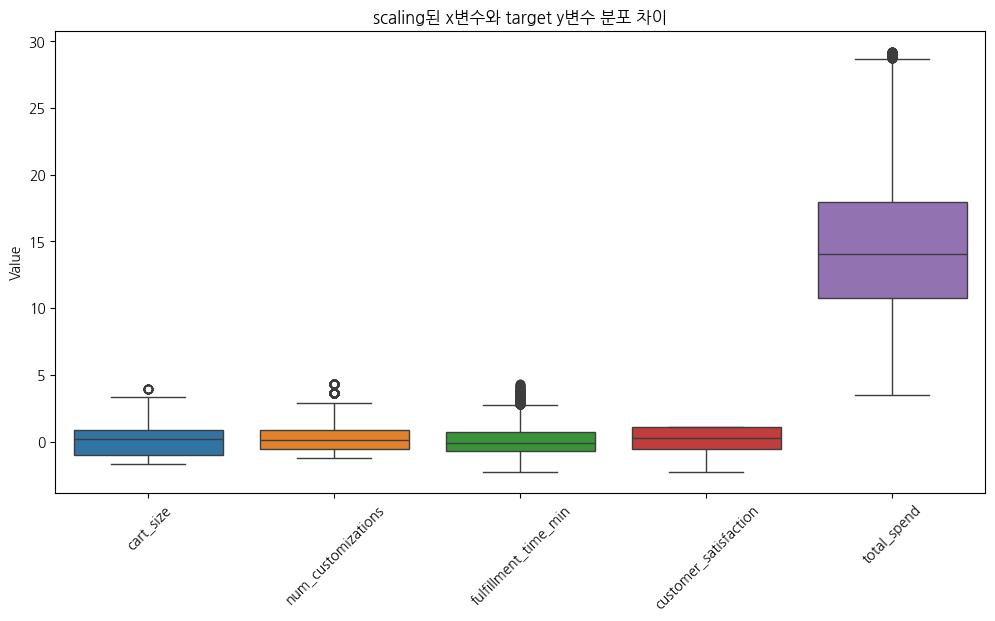

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 스케일링된 X_train 데이터와 Y_train을 결합하여 새로운 데이터프레임 생성
# Y_train Series의 name이 'total_spend'이므로, 직접 컬럼으로 추가하여 중복 방지
df_combined_scaled = df_scale.copy()
df_combined_scaled['total_spend'] = Y_train

# 1. 비교를 위해 스케일링된 X_train 데이터와 Y_train 결합
plt.figure(figsize=(12,6))
sns.boxplot(data=df_combined_scaled)
plt.xticks(rotation=45)
plt.title('scaling된 x변수와 target y변수 분포 차이')
plt.ylabel('Value')
plt.show()

### 1. 타겟 변수 로그 변환 및 모델 학습
타겟 변수인 `total_spend`에 로그 변환을 적용하여 정규성을 높인 뒤, 선형 회귀 모델을 다시 학습시키고 성능을 평가합니다.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 1. 타겟 변수 로그 변환 (log(1+x))
Y_train_log = np.log1p(Y_train)
Y_test_log = np.log1p(Y_test)

# 2. 모델 학습 (로그 변환된 타겟 사용)
lr_log = LinearRegression()
lr_log.fit(X_train, Y_train_log)

# 3. 예측 수행
Y_pred_log = lr_log.predict(X_test)

# 4. 성능 평가를 위해 원래 단위로 복원 (exp(x)-1)
Y_pred_back = np.expm1(Y_pred_log)

# 5. 지표 계산
mse_log = mean_squared_error(Y_test, Y_pred_back)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(Y_test, Y_pred_back)

print("=== log1p 로그 변환 적용 후 성능 ===")
print(f"RMSE: {rmse_log:.4f}")
print(f"R²  : {r2_log:.4f}")

print("\n=== 변환 전 비교 ===")
print(f"이전 RMSE: {rmse:.4f}")
print(f"이전 R²  : {r2:.4f}")

=== log1p 로그 변환 적용 후 성능 ===
RMSE: 1.4348
R²  : 0.9233

=== 변환 전 비교 ===
이전 RMSE: 0.9673
이전 R²  : 0.9652


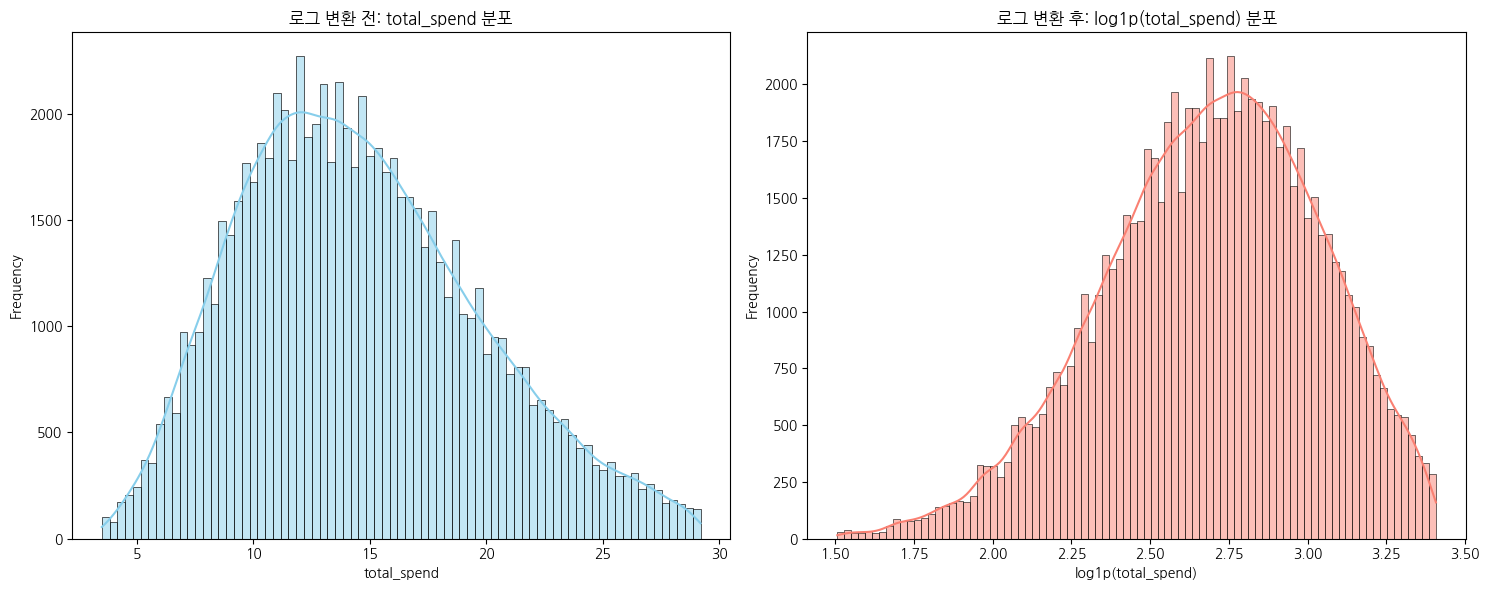

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import koreanize_matplotlib

# 1. 로그 변환 전후 데이터 준비
y_original = Y_train
y_log_transformed = np.log1p(Y_train) #log1p 사용하면 0도

# 2. 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 로그 변환 전 분포
sns.histplot(y_original, kde=True, ax=ax1, color='skyblue')
ax1.set_title('로그 변환 전: total_spend 분포')
ax1.set_xlabel('total_spend')
ax1.set_ylabel('Frequency')

# 로그 변환 후 분포
sns.histplot(y_log_transformed, kde=True, ax=ax2, color='salmon')
ax2.set_title('로그 변환 후: log1p(total_spend) 분포')
ax2.set_xlabel('log1p(total_spend)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# 왜도(skewness) 수치로 확인
from scipy import stats
print(f"변환 전 왜도: {stats.skew(y_original):.3f}")
print(f"변환 후 왜도: {stats.skew(y_log_transformed):.3f}")

# Box-Cox 변환 시도 (더 유연한 변환)
from scipy.stats import boxcox
y_boxcox, lambda_ = boxcox(Y_train + 1)

변환 전 왜도: 0.442
변환 후 왜도: -0.352


In [ ]:
# Box-Cox로 더 정밀하게 조정
from scipy.stats import boxcox
y_boxcox, lambda_ = boxcox(Y_train + 1)
print(f"Box-Cox 왜도: {stats.skew(y_boxcox):.3f}")
print(f"최적 lambda: {lambda_:.3f}")
# lambda ≈ 1이면 변환 불필요, ≈ 0이면 log변환과 유사

Box-Cox 왜도: -0.020
최적 lambda: 0.396


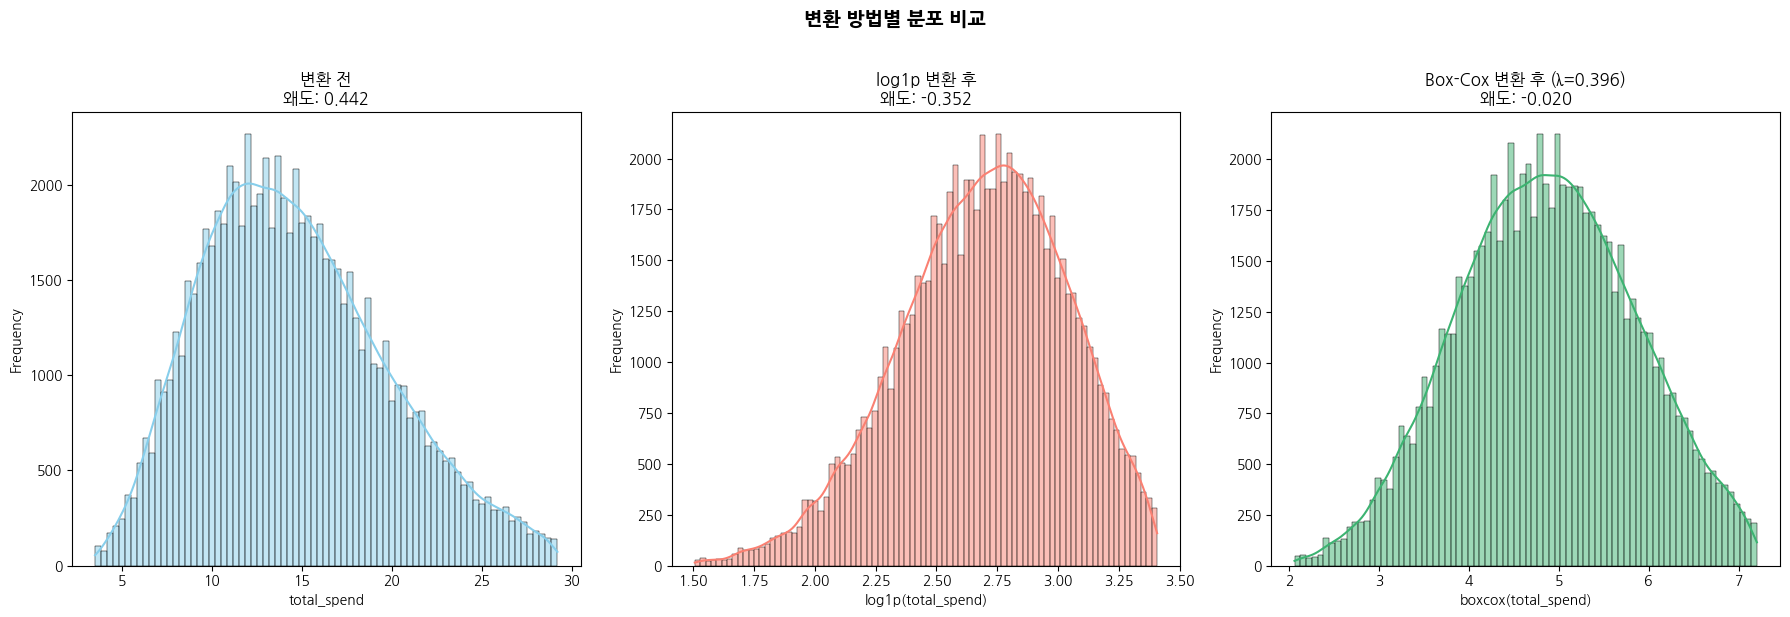

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import boxcox

# 변환 데이터 준비
y_original = Y_train
y_log_transformed = np.log1p(Y_train)
y_boxcox, lambda_ = boxcox(Y_train + 1)

# 왜도 계산
skew_original = stats.skew(y_original)
skew_log = stats.skew(y_log_transformed)
skew_boxcox = stats.skew(y_boxcox)

# 시각화 (3개 비교)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# 1. 변환 전
sns.histplot(y_original, kde=True, ax=ax1, color='skyblue')
ax1.set_title(f'변환 전\n왜도: {skew_original:.3f}')
ax1.set_xlabel('total_spend')
ax1.set_ylabel('Frequency')

# 2. log1p 변환 후
sns.histplot(y_log_transformed, kde=True, ax=ax2, color='salmon')
ax2.set_title(f'log1p 변환 후\n왜도: {skew_log:.3f}')
ax2.set_xlabel('log1p(total_spend)')
ax2.set_ylabel('Frequency')

# 3. Box-Cox 변환 후
sns.histplot(y_boxcox, kde=True, ax=ax3, color='mediumseagreen')
ax3.set_title(f'Box-Cox 변환 후 (λ={lambda_:.3f})\n왜도: {skew_boxcox:.3f}')
ax3.set_xlabel('boxcox(total_spend)')
ax3.set_ylabel('Frequency')

plt.suptitle('변환 방법별 분포 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1. 잔차 분석 (Error Analysis)
모델이 예측한 값과 실제값의 차이인 잔차(Residual)를 시각화하여 모델의 성능을 진단합니다.

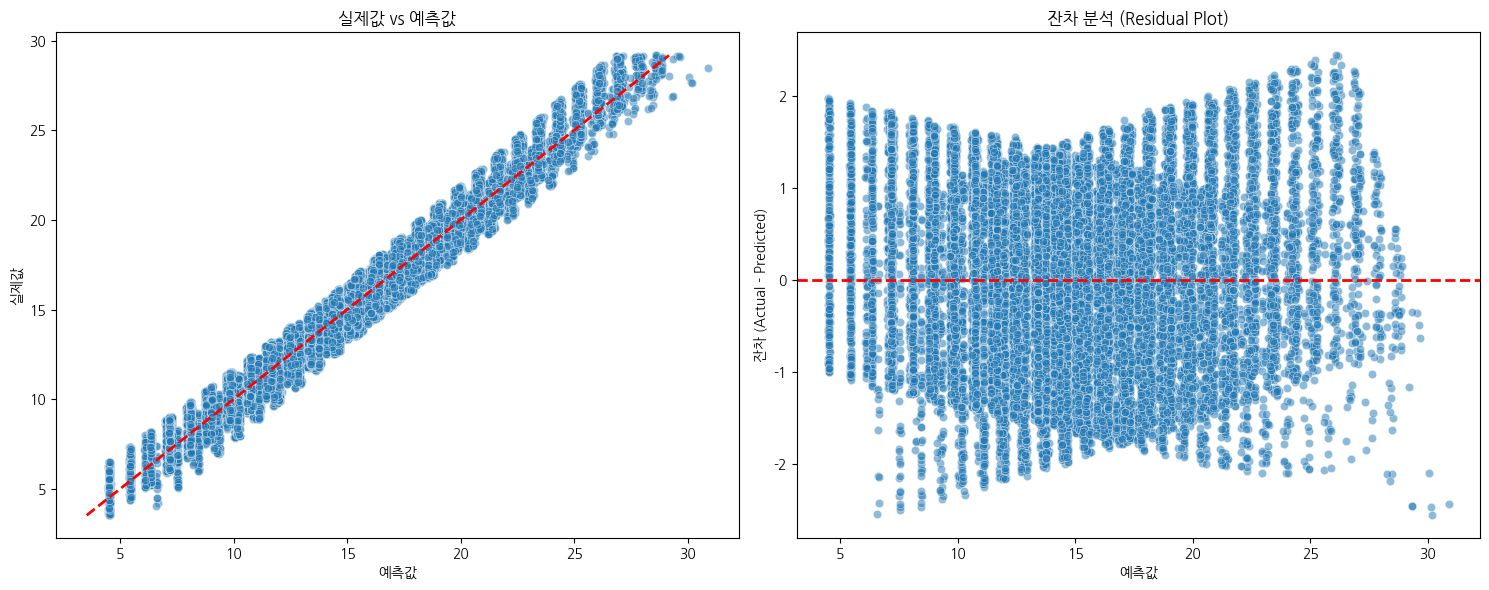

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 잔차 계산
residuals = Y_test - Y_pred

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. 예측값 vs 실제값 산점도
sns.scatterplot(x=Y_pred, y=Y_test, ax=ax[0], alpha=0.5)
ax[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
ax[0].set_title('실제값 vs 예측값')
ax[0].set_xlabel('예측값')
ax[0].set_ylabel('실제값')

# 2. 잔차도 (Residual Plot)
sns.scatterplot(x=Y_pred, y=residuals, ax=ax[1], alpha=0.5)
ax[1].axhline(y=0, color='r', linestyle='--', lw=2)
ax[1].set_title('잔차 분석 (Residual Plot)')
ax[1].set_xlabel('예측값')
ax[1].set_ylabel('잔차 (Actual - Predicted)')

plt.tight_layout()
plt.show()

[Box-Cox 모델] RMSE: 1.0674, R²: 0.9576


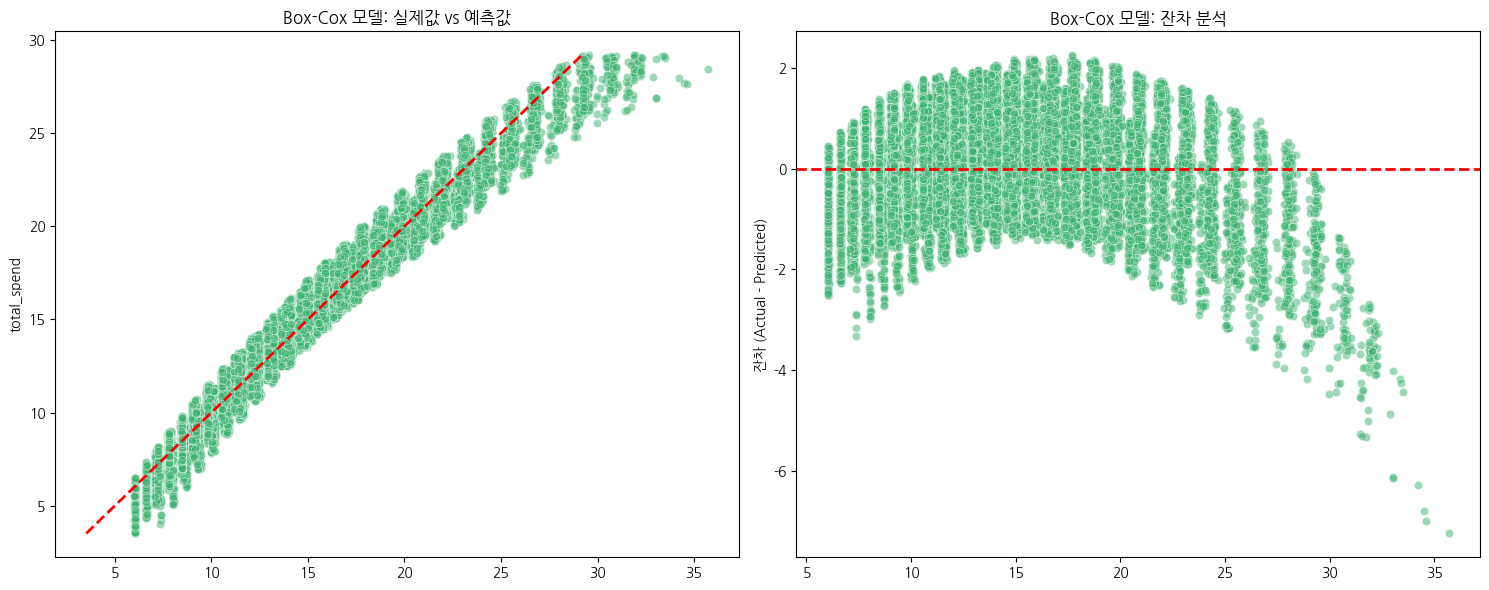

In [ ]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# 1. Box-Cox 변환 (훈련 데이터와 테스트 데이터 동일 람다 적용)
Y_train_bc, maxlog = boxcox(Y_train + 1)
Y_test_bc = boxcox(Y_test + 1, lmbda=maxlog)

# 2. Box-Cox 변환 타겟으로 모델 재학습
lr_bc = LinearRegression()
lr_bc.fit(X_train, Y_train_bc)

# 3. 예측 및 역변환 (평가를 위해 원래 단위로 복원)
Y_pred_bc = lr_bc.predict(X_test)
Y_pred_bc_back = inv_boxcox(Y_pred_bc, maxlog) - 1

# 4. 성능 확인
rmse_bc = np.sqrt(mean_squared_error(Y_test, Y_pred_bc_back))
r2_bc = r2_score(Y_test, Y_pred_bc_back)

print(f"[Box-Cox 모델] RMSE: {rmse_bc:.4f}, R²: {r2_bc:.4f}")

# 5. Box-Cox 모델 기반 잔차 분석 시각화
residuals_bc = Y_test - Y_pred_bc_back

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 실제값 vs 예측값
sns.scatterplot(x=Y_pred_bc_back, y=Y_test, ax=ax[0], alpha=0.5, color='mediumseagreen')
ax[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
ax[0].set_title('Box-Cox 모델: 실제값 vs 예측값')

# 잔차도
sns.scatterplot(x=Y_pred_bc_back, y=residuals_bc, ax=ax[1], alpha=0.5, color='mediumseagreen')
ax[1].axhline(y=0, color='r', linestyle='--', lw=2)
ax[1].set_title('Box-Cox 모델: 잔차 분석')
ax[1].set_ylabel('잔차 (Actual - Predicted)')

plt.tight_layout()
plt.show()

### 2. 다른 모델 시도 및 비교 (Ridge, Lasso)
규제(Regularization)가 포함된 Ridge와 Lasso 모델을 학습시켜 성능을 비교합니다.

In [ ]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# CV를 사용하여 최적 alpha 자동 탐색
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000])
ridge_cv.fit(X_train, Y_train)
best_ridge_alpha = ridge_cv.alpha_

lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10])
lasso_cv.fit(X_train, Y_train)
best_lasso_alpha = lasso_cv.alpha_

print(f"Ridge 최적 alpha: {best_ridge_alpha}")
print(f"Lasso 최적 alpha: {best_lasso_alpha}\n")

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=best_ridge_alpha),
    'Lasso': Lasso(alpha=best_lasso_alpha)
}

# 모델 정의
# models = {
#     'LinearRegression': LinearRegression(), # 제한 없이 계수 학습
#     'Ridge': Ridge(alpha=1.0),           # 계수를 0에 가깝게 줄임
#     'Lasso': Lasso(alpha=0.01)          # 중요하지 않은 계수를 0으로 만듦(불필요한 피처 제거)
# }

results = []

# 학습 및 평가
for name, model in models.items():
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)

    # 평가지표 계산
    mae_val = mean_absolute_error(Y_test, pred)
    mse_val = mean_squared_error(Y_test, pred)
    rmse_val = np.sqrt(mse_val)
    r2_val = r2_score(Y_test, pred)

    # 과적합 확인을 위한 훈련 데이터 R2 계산
    train_r2 = r2_score(Y_train, model.predict(X_train))

    results.append({
        'Model': name,
        'MAE': mae_val,
        'MSE': mse_val,
        'RMSE': rmse_val,
        'R2': r2_val,
    })

# 결과 출력
print('모델별 성능 비교\n')
for res in results:
    print(f"[ {res['Model']} ]")
    print(f"  MAE        : {res['MAE']:.4f}")
    print(f"  MSE        : {res['MSE']:.4f}")
    print(f"  RMSE       : {res['RMSE']:.4f}")
    print(f"  R²         : {res['R2']:.4f}")
    print('-' * 30)

# 최적 모델 자동 선택 (RMSE 기준)
best = min(results, key=lambda x: x['RMSE'])
print(f"\n 최적 모델: {best['Model']} (RMSE: {best['RMSE']:.4f})")

Ridge 최적 alpha: 1.0
Lasso 최적 alpha: 0.001

모델별 성능 비교

[ LinearRegression ]
  MAE        : 0.8219
  MSE        : 0.9356
  RMSE       : 0.9673
  R²         : 0.9652
------------------------------
[ Ridge ]
  MAE        : 0.8219
  MSE        : 0.9356
  RMSE       : 0.9673
  R²         : 0.9652
------------------------------
[ Lasso ]
  MAE        : 0.8218
  MSE        : 0.9352
  RMSE       : 0.9671
  R²         : 0.9652
------------------------------

 최적 모델: Lasso (RMSE: 0.9671)


In [ ]:
from sklearn.model_selection import cross_val_score # 과적합 방지를 위한 cross_Validation
import numpy as np

print('\n교차검증 결과\n')
for name, model in models.items():
    r2_scores    = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2') # 데이터를 5등분
    mae_scores   = cross_val_score(model, X_train, Y_train, cv=5, scoring='neg_mean_absolute_error')
    mse_scores  = cross_val_score(model, X_train, Y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores  = cross_val_score(model, X_train, Y_train, cv=5, scoring='neg_root_mean_squared_error')

    print(f"[ {name} ]")
    print(f"  CV R²   평균: {r2_scores.mean():.4f}  / 편차: {r2_scores.std():.4f}")
    print(f"  CV MAE  평균: {(-mae_scores).mean():.4f}  / 편차: {(-mae_scores).std():.4f}")
    print(f"  CV MSE 평균: {(-mse_scores).mean():.4f}  / 편차: {(rmse_scores).std():.4f}")
    print(f"  CV RMSE 평균: {(-rmse_scores).mean():.4f}  / 편차: {(-rmse_scores).std():.4f}")
    print('-' * 30)


교차검증 결과

[ LinearRegression ]
  CV R²   평균: 0.9646  / 편차: 0.0007
  CV MAE  평균: 0.8228  / 편차: 0.0056
  CV MSE 평균: 0.9359  / 편차: 0.0045
  CV RMSE 평균: 0.9674  / 편차: 0.0045
------------------------------
[ Ridge ]
  CV R²   평균: 0.9646  / 편차: 0.0007
  CV MAE  평균: 0.8228  / 편차: 0.0056
  CV MSE 평균: 0.9359  / 편차: 0.0045
  CV RMSE 평균: 0.9674  / 편차: 0.0045
------------------------------
[ Lasso ]
  CV R²   평균: 0.9646  / 편차: 0.0007
  CV MAE  평균: 0.8226  / 편차: 0.0056
  CV MSE 평균: 0.9356  / 편차: 0.0045
  CV RMSE 평균: 0.9673  / 편차: 0.0045
------------------------------


### 4. 다양한 모델을 결합한 앙상블 (Simple Averaging Ensemble)

단일 앙상블 모델인 `RandomForest`뿐만 아니라, `LinearRegression`, `Ridge`, `Lasso` 모델과 `RandomForest` 모델의 예측을 결합하여 더욱 안정적이고 강력한 예측 성능을 가진 앙상블 모델을 구성해 보겠습니다. 여기서는 간단한 평균 앙상블(Simple Averaging Ensemble) 방식을 사용합니다.

In [ ]:
pip install lightgbm

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. 개별 모델 정의 (이미 앞에서 최적 alpha를 찾았으므로 해당 값을 사용)
# LinearRegression 모델은 이미 'lr' 객체로 정의되어 있음
# Ridge 모델은 'models' 딕셔너리에서 가져오거나 새로 정의
# Lasso 모델은 'models' 딕셔너리에서 가져오거나 새로 정의
# RandomForest 모델은 'rf_model' 객체로 정의되어 있음

# Ridge 및 Lasso 모델의 alpha 값을 확인 (이전 셀에서 계산된 최적 alpha 사용)
best_ridge_alpha = 1.0 # 이전 실행 결과에서 얻은 값
best_lasso_alpha = 0.001 # 이전 실행 결과에서 얻은 값

model_lr = LinearRegression()
model_ridge = Ridge(alpha=best_ridge_alpha)
model_lasso = Lasso(alpha=best_lasso_alpha)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. 각 모델 학습
model_lr.fit(X_train, Y_train)
model_ridge.fit(X_train, Y_train)
model_lasso.fit(X_train, Y_train)
model_rf.fit(X_train, Y_train)

# 3. 각 모델의 예측값 생성
pred_lr = model_lr.predict(X_test)
pred_ridge = model_ridge.predict(X_test)
pred_lasso = model_lasso.predict(X_test)
pred_rf = model_rf.predict(X_test)

# Box-Cox 모델의 예측값 (Y_pred_bc_back)은 사용자 요청에 따라 제외
# 4. 예측값 평균하여 앙상블 예측값 생성 (Box-Cox 모델 예측값 제외, 4개 모델)
Y_pred_ensemble = (pred_lr + pred_ridge + pred_lasso + pred_rf) / 4

# 5. 앙상블 모델 성능 평가
mae_ensemble = mean_absolute_error(Y_test, Y_pred_ensemble)
mse_ensemble = mean_squared_error(Y_test, Y_pred_ensemble)
rmse_ensemble = np.sqrt(mse_ensemble)
r2_ensemble = r2_score(Y_test, Y_pred_ensemble)

print("=== 앙상블 모델 (LinearRegression, Ridge, Lasso, RandomForest 평균, Box-Cox 제외) 성능 ===")
print(f"MAE  : {mae_ensemble:.4f}")
print(f"MSE  : {mse_ensemble:.4f}")
print(f"RMSE : {rmse_ensemble:.4f}")
print(f"R²   : {r2_ensemble:.4f}")

# 6. 기존 최적 모델 (Lasso)과 비교
lasso_best_rmse = 0.9671 # 이전 Lasso 모델의 RMSE 값
lasso_best_r2 = 0.9652   # 이전 Lasso 모델의 R2 값

print("\n=== 기존 최적 Lasso 모델과의 비교 ===")
print(f"Lasso RMSE: {lasso_best_rmse:.4f} -> Ensemble RMSE: {rmse_ensemble:.4f}")
print(f"Lasso R²  : {lasso_best_r2:.4f} -> Ensemble R²  : {r2_ensemble:.4f}")

if rmse_ensemble < lasso_best_rmse:
    print("\n결론: 앙상블 모델이 기존 최적 Lasso 모델보다 RMSE가 낮아 성능이 개선되었습니다.")
elif rmse_ensemble == lasso_best_rmse:
    print("\n결론: 앙상블 모델의 성능이 기존 최적 Lasso 모델과 유사합니다.")
else:
    print("\n결론: 앙상블 모델이 기존 최적 Lasso 모델보다 RMSE가 높아 성능이 저하되었습니다.")

=== 앙상블 모델 (LinearRegression, Ridge, Lasso, RandomForest 평균, Box-Cox 제외) 성능 ===
MAE  : 0.8097
MSE  : 0.8984
RMSE : 0.9478
R²   : 0.9665

=== 기존 최적 Lasso 모델과의 비교 ===
Lasso RMSE: 0.9671 -> Ensemble RMSE: 0.9478
Lasso R²  : 0.9652 -> Ensemble R²  : 0.9665

결론: 앙상블 모델이 기존 최적 Lasso 모델보다 RMSE가 낮아 성능이 개선되었습니다.


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import lightgbm as lgb

# 1. 개별 모델 정의 (이미 앞에서 최적 alpha를 찾았으므로 해당 값을 사용)
# Ridge 및 Lasso 모델의 alpha 값을 확인 (이전 셀에서 계산된 최적 alpha 사용)
best_ridge_alpha = 1.0 # 이전 실행 결과에서 얻은 값
best_lasso_alpha = 0.001 # 이전 실행 결과에서 얻은 값

model_lr = LinearRegression()
model_ridge = Ridge(alpha=best_ridge_alpha)
model_lasso = Lasso(alpha=best_lasso_alpha)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1) # LightGBM 모델 추가

# 2. 각 모델 학습
model_lr.fit(X_train, Y_train)
model_ridge.fit(X_train, Y_train)
model_lasso.fit(X_train, Y_train)
model_rf.fit(X_train, Y_train)
model_lgbm.fit(X_train, Y_train) # LightGBM 학습

# 3. 각 모델의 예측값 생성
pred_lr = model_lr.predict(X_test)
pred_ridge = model_ridge.predict(X_test)
pred_lasso = model_lasso.predict(X_test)
pred_rf = model_rf.predict(X_test)
pred_lgbm = model_lgbm.predict(X_test) # LightGBM 예측값 생성

# Box-Cox 모델의 예측값 (Y_pred_bc_back)은 사용자 요청에 따라 제외
# 4. 예측값 평균하여 앙상블 예측값 생성 (Box-Cox 모델 예측값 제외, 5개 모델)
Y_pred_ensemble_lgbm = (pred_lr + pred_ridge + pred_lasso + pred_rf + pred_lgbm) / 5

# 5. 앙상블 모델 성능 평가
mae_ensemble_lgbm = mean_absolute_error(Y_test, Y_pred_ensemble_lgbm)
mse_ensemble_lgbm = mean_squared_error(Y_test, Y_pred_ensemble_lgbm)
rmse_ensemble_lgbm = np.sqrt(mse_ensemble_lgbm)
r2_ensemble_lgbm = r2_score(Y_test, Y_pred_ensemble_lgbm)

print("=== 앙상블 모델 (LinearRegression, Ridge, Lasso, RandomForest, LightGBM 평균, Box-Cox 제외) 성능 ===")
print(f"MAE  : {mae_ensemble_lgbm:.4f}")
print(f"MSE  : {mse_ensemble_lgbm:.4f}")
print(f"RMSE : {rmse_ensemble_lgbm:.4f}")
print(f"R²   : {r2_ensemble_lgbm:.4f}")

# 6. 기존 최적 모델 (이전 앙상블)과 비교
# Ensure prev_ensemble_rmse and prev_ensemble_r2 reflect the previous ensemble WITHOUT Box-Cox
prev_ensemble_rmse = rmse_ensemble # This will now refer to the ensemble from ae27bdff (without BC)
prev_ensemble_r2 = r2_ensemble   # This will now refer to the ensemble from ae27bdff (without BC)

print("\n=== 기존 앙상블 모델과의 비교 ===")
print(f"이전 앙상블 RMSE: {prev_ensemble_rmse:.4f} -> 현재 앙상블 RMSE: {rmse_ensemble_lgbm:.4f}")
print(f"이전 앙상블 R²  : {prev_ensemble_r2:.4f} -> 현재 앙상블 R²  : {r2_ensemble_lgbm:.4f}")

if rmse_ensemble_lgbm < prev_ensemble_rmse:
    print("\n결론: LightGBM이 추가된 앙상블 모델이 기존 앙상블 모델보다 RMSE가 낮아 성능이 개선되었습니다.")
elif rmse_ensemble_lgbm == prev_ensemble_rmse:
    print("\n결론: LightGBM이 추가된 앙상블 모델의 성능이 기존 앙상블 모델과 유사합니다.")
else:
    print("\n결론: LightGBM이 추가된 앙상블 모델이 기존 앙상블 모델보다 RMSE가 높아 성능이 저하되었습니다.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 78868, number of used features: 40
[LightGBM] [Info] Start training from score 14.612349
=== 앙상블 모델 (LinearRegression, Ridge, Lasso, RandomForest, LightGBM 평균, Box-Cox 제외) 성능 ===
MAE  : 0.8032
MSE  : 0.8786
RMSE : 0.9373
R²   : 0.9673

=== 기존 앙상블 모델과의 비교 ===
이전 앙상블 RMSE: 0.9478 -> 현재 앙상블 RMSE: 0.9373
이전 앙상블 R²  : 0.9665 -> 현재 앙상블 R²  : 0.9673

결론: LightGBM이 추가된 앙상블 모델이 기존 앙상블 모델보다 RMSE가 낮아 성능이 개선되었습니다.


In [ ]:
print("Current columns in df_final:")
print(df_final.columns.tolist())

Current columns in df_final:
['is_rewards_member', 'cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min', 'has_food_item', 'order_ahead', 'customer_satisfaction', 'total_orders_x', 'avg_satisfaction_x', 'total_orders_y', 'avg_satisfaction_y', 'day_of_week_Mon', 'day_of_week_Sat', 'day_of_week_Sun', 'day_of_week_Thu', 'day_of_week_Tue', 'day_of_week_Wed', 'order_channel_In-Store Cashier', 'order_channel_Kiosk', 'order_channel_Mobile App', 'store_location_type_Suburban', 'store_location_type_Urban', 'region_Northeast', 'region_Southeast', 'region_Southwest', 'region_West', 'customer_age_group_25-34', 'customer_age_group_35-44', 'customer_age_group_45-54', 'customer_age_group_55+', 'customer_gender_Male', 'customer_gender_Non-binary', 'customer_gender_Prefer not to say', 'drink_category_Espresso', 'drink_category_Frappuccino', 'drink_category_Other', 'drink_category_Refresher', 'drink_category_Tea', 'order_hour', 'order_minute']


In [ ]:
pip install xgboost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# 테스트 데이터 20%로 설정, X, Y를 토대로 훈련 데이터, 테스트 데이터 생성

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train, X_test)
print(Y_train, Y_test)

       is_rewards_member  cart_size  num_customizations  fulfillment_time_min  \
70059               True          1                   1                   3.8   
69797              False          2                   2                   2.5   
45795              False          2                   4                   4.2   
86558              False          1                   0                   2.5   
74273               True          2                   1                   3.9   
...                  ...        ...                 ...                   ...   
6265                True          3                   0                   7.3   
54886              False          2                   0                   2.8   
76820              False          6                   4                   3.3   
860                False          2                   1                   2.3   
15795               True          1                   0                   5.1   

       has_food_item  order

In [ ]:
# StandardScaler 표준화를 이용하여 변수 간 값의 범위 차이를 줄이기

scale_cols = ['cart_size', 'num_customizations', 'fulfillment_time_min', 'customer_satisfaction']

scaler = StandardScaler() # 평균0, 표준편차 1인 값으로 표준화 실행
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols]) # test는 fit 없음

# 스케일링 진행 후 넘파이로 된 것 ->DataFrame만들어주기
df_scale = pd.DataFrame(X_train[scale_cols], columns=scale_cols)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import numpy as np
import pandas as pd

# Re-define best alphas from previous runs for consistency
best_ridge_alpha = 1.0
best_lasso_alpha = 0.001
maxlog = 0.3955778560471175 # from 0b4bee6e

# Helper functions for Box-Cox transformation (for TransformedTargetRegressor)
# These functions are kept for now as other parts of the notebook might still reference them,
# but the Box-Cox model itself will be removed from the comparison.
def boxcox_transform(y):
    # Ensure y is always 1D for boxcox, and return 1D result
    y_flat = np.asarray(y).ravel()
    transformed_y = boxcox(y_flat + 1, lmbda=maxlog)[0]
    # TransformedTargetRegressor expects (n_samples, n_targets) for its internal regressor
    # if n_targets=1, it means (n_samples, 1). LinearRegression can handle 1D too,
    # but to be consistent with TransformedTargetRegressor's internal logic, returning 2D.
    return transformed_y.reshape(-1, 1)

def inv_boxcox_transform(y_transformed):
    # Ensure y_transformed is always 1D for inv_boxcox, and return 1D result
    y_flat = np.asarray(y_transformed).ravel() # Ensure it's 1D before inv_boxcox
    original_y = inv_boxcox(y_flat, maxlog) - 1
    return original_y.reshape(-1, 1)


# 1. Define all individual models for comparison
# Exclude 'LinearRegression_BoxCox' as requested by the user
all_individual_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=best_ridge_alpha),
    'Lasso': Lasso(alpha=best_lasso_alpha),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42), # Default alpha and l1_ratio
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoostingRegressor': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'LGBMRegressor': LGBMRegressor(random_state=42, n_jobs=-1),
    'XGBRegressor': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1),
}

results_individual_models = []

print("=== Individual Model Training and Evaluation ===")
for name, model in all_individual_models.items():
    print(f"Training {name}...")
    # For models using TransformedTargetRegressor, Y_train should be the original Y_train
    # The TransformedTargetRegressor handles the transformation internally during fit and inverse transformation during predict
    # Removed Y_train.values.ravel() as TransformedTargetRegressor expects the original Y_train and handles reshaping internally
    model.fit(X_train, Y_train)

    pred = model.predict(X_test)

    mae_val = mean_absolute_error(Y_test, pred)
    mse_val = mean_squared_error(Y_test, pred)
    rmse_val = np.sqrt(mse_val)
    r2_val = r2_score(Y_test, pred)

    results_individual_models.append({
        'Model': name,
        'MAE': mae_val,
        'MSE': mse_val,
        'RMSE': rmse_val,
        'R2': r2_val,
    })
    print(f"  {name} - RMSE: {rmse_val:.4f}, R²: {r2_val:.4f}")
    print("-" * 30)

df_individual_results = pd.DataFrame(results_individual_models)
print("\n=== Individual Model Performance Summary (Sorted by RMSE) ===")
display(df_individual_results.sort_values(by='RMSE'))

# Add the ensemble results from previous cells for a comprehensive comparison
all_comparison_results = df_individual_results.copy()

ensemble_results = []
# Check if previous ensemble results are available in the kernel (from cell ae27bdff and d3c97a66)
# NOTE: Y_pred_bc_back is excluded from these ensemble calculations as per user request.
if 'mae_ensemble' in globals() and 'rmse_ensemble' in globals() and 'r2_ensemble' in globals():
    ensemble_results.append({
        'Model': 'Simple Averaging (LR+Ridge+Lasso+RF, NO BC)', # Updated model name
        'MAE': mae_ensemble,
        'MSE': mse_ensemble,
        'RMSE': rmse_ensemble,
        'R2': r2_ensemble
    })
if 'mae_ensemble_lgbm' in globals() and 'rmse_ensemble_lgbm' in globals() and 'r2_ensemble_lgbm' in globals():
    ensemble_results.append({
        'Model': 'Simple Averaging (LR+Ridge+Lasso+RF+LGBM, NO BC)', # Updated model name
        'MAE': mae_ensemble_lgbm,
        'MSE': mse_ensemble_lgbm,
        'RMSE': rmse_ensemble_lgbm,
        'R2': r2_ensemble_lgbm
    })

if ensemble_results:
    all_comparison_results = pd.concat([all_comparison_results, pd.DataFrame(ensemble_results)], ignore_index=True)

print("\n=== Comprehensive Model Performance Comparison (Individual & Ensemble, Sorted by RMSE) ===")
display(all_comparison_results.sort_values(by='RMSE'))

print(f"\n최적 모델: {all_comparison_results.sort_values(by='RMSE').iloc[0]['Model']} (RMSE: {all_comparison_results.sort_values(by='RMSE').iloc[0]['RMSE']:.4f}, R²: {all_comparison_results.sort_values(by='RMSE').iloc[0]['R2']:.4f})")

=== Individual Model Training and Evaluation ===
Training LinearRegression...
  LinearRegression - RMSE: 0.9673, R²: 0.9652
------------------------------
Training Ridge...
  Ridge - RMSE: 0.9673, R²: 0.9652
------------------------------
Training Lasso...
  Lasso - RMSE: 0.9671, R²: 0.9652
------------------------------
Training ElasticNet...
  ElasticNet - RMSE: 2.4974, R²: 0.7677
------------------------------
Training RandomForestRegressor...
  RandomForestRegressor - RMSE: 0.9462, R²: 0.9667
------------------------------
Training GradientBoostingRegressor...
  GradientBoostingRegressor - RMSE: 0.9210, R²: 0.9684
------------------------------
Training LGBMRegressor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011028 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] 

,Model,MAE,MSE,RMSE,R2
7,XGBRegressor,0.792084,0.846355,0.919976,0.968483
6,LGBMRegressor,0.792268,0.846369,0.919983,0.968482
5,GradientBoostingRegressor,0.793207,0.848317,0.921041,0.968409
4,RandomForestRegressor,0.806749,0.895316,0.946211,0.966659
2,Lasso,0.821812,0.935230,0.967073,0.965173
1,Ridge,0.821929,0.935635,0.967282,0.965158
0,LinearRegression,0.821930,0.935636,0.967283,0.965158
3,ElasticNet,2.009979,6.237123,2.497423,0.767735



=== Comprehensive Model Performance Comparison (Individual & Ensemble, Sorted by RMSE) ===


,Model,MAE,MSE,RMSE,R2
7,XGBRegressor,0.792084,0.846355,0.919976,0.968483
6,LGBMRegressor,0.792268,0.846369,0.919983,0.968482
5,GradientBoostingRegressor,0.793207,0.848317,0.921041,0.968409
9,"Simple Averaging (LR+Ridge+Lasso+RF+LGBM, NO BC)",0.803207,0.878621,0.937348,0.967281
4,RandomForestRegressor,0.806749,0.895316,0.946211,0.966659
8,"Simple Averaging (LR+Ridge+Lasso+RF, NO BC)",0.809661,0.898386,0.947832,0.966545
2,Lasso,0.821812,0.935230,0.967073,0.965173
1,Ridge,0.821929,0.935635,0.967282,0.965158
0,LinearRegression,0.821930,0.935636,0.967283,0.965158
3,ElasticNet,2.009979,6.237123,2.497423,0.767735



최적 모델: XGBRegressor (RMSE: 0.9200, R²: 0.9685)


### 8. 스태킹 앙상블 (Stacking Ensemble)

이제 여러 개별 모델들의 예측을 조합하는 더욱 정교한 앙상블 기법인 **스태킹(Stacking)**을 적용하여 모델 성능을 개선해 보겠습니다. 스태킹은 여러 `Base 모델`의 예측값을 학습하여 최종 예측을 수행하는 `Meta 모델`을 훈련하는 방식입니다.

여기서는 `LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor`, `LGBMRegressor`, `XGBRegressor`를 Base 모델로 사용하고, `LinearRegression`을 Meta 모델로 사용하여 스태킹 앙상블을 구축합니다.

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- 1. Base Models 정의 ---
# 이전에 훈련된 또는 최적화된 모델들을 활용합니다.
# XGBRegressor는 튜닝된 최적 파라미터로 초기화합니다.

# Best alphas and XGBoost parameters from previous runs
best_ridge_alpha = 1.0
best_lasso_alpha = 0.001

# Tuned XGBoost parameters from cell 4979adbe
tuned_xgb_params = {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 0.005, 'subsample': 0.8}

estimators = [
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=best_ridge_alpha)),
    ('lasso', Lasso(alpha=best_lasso_alpha)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMRegressor(random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(random_state=42, n_jobs=-1, **tuned_xgb_params)) # Use tuned params
]

# --- 2. Meta Learner 정의 ---
# 최종 예측을 수행할 모델입니다.
meta_learner = LinearRegression()

# --- 3. StackingRegressor 설정 ---
# cv는 Base 모델의 예측을 생성하고 Meta 모델을 훈련하는 데 사용될 폴드 수입니다.
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5, # 교차 검증 폴드 수
    n_jobs=-1, # 모든 코어 사용
    passthrough=True # Base 모델에 사용된 특성을 Meta 모델에 전달할지 여부
)

# --- 4. Stacking 모델 학습 ---
print("Starting Stacking Ensemble training...")
stacking_model.fit(X_train, Y_train)
print("Stacking Ensemble training completed.")

# --- 5. 예측 수행 ---
Y_pred_stacking = stacking_model.predict(X_test)

# --- 6. 성능 평가 ---
mae_stacking = mean_absolute_error(Y_test, Y_pred_stacking)
mse_stacking = mean_squared_error(Y_test, Y_pred_stacking)
rmse_stacking = np.sqrt(mse_stacking)
r2_stacking = r2_score(Y_test, Y_pred_stacking)

print("\n=== Stacking Ensemble Model Performance (Base: LR, Ridge, Lasso, RF, LGBM, XGB) ===")
print(f"MAE  : {mae_stacking:.4f}")
print(f"MSE  : {mse_stacking:.4f}")
print(f"RMSE : {rmse_stacking:.4f}")
print(f"R²   : {r2_stacking:.4f}")

# --- 7. 기존 최적 모델 (XGBRegressor 튜닝)과 비교 ---
# 튜닝된 XGBRegressor의 RMSE와 R2 값을 사용합니다.
# These values are from the output of cell 4979adbe
previous_best_rmse = 0.9192 # Tuned XGBRegressor Test RMSE
previous_best_r2 = 0.9685   # Tuned XGBRegressor Test R²

print("\n=== 기존 최적 모델 (튜닝된 XGBRegressor)과의 비교 ===")
print(f"기존 최적 모델 RMSE: {previous_best_rmse:.4f} -> Stacking Ensemble RMSE: {rmse_stacking:.4f}")
print(f"기존 최적 모델 R²  : {previous_best_r2:.4f} -> Stacking Ensemble R²  : {r2_stacking:.4f}")

if rmse_stacking < previous_best_rmse:
    print("\n결론: 스태킹 앙상블 모델이 기존 최적 모델보다 RMSE가 낮아 성능이 개선되었습니다!")
elif rmse_stacking == previous_best_rmse:
    print("\n결론: 스태킹 앙상블 모델의 성능이 기존 최적 모델과 유사합니다.")
else:
    print("\n결론: 스태킹 앙상블 모델이 기존 최적 모델보다 RMSE가 높아 성능이 저하되었습니다. Base 모델이나 Meta 모델을 변경하여 시도해 볼 수 있습니다.")



Starting Stacking Ensemble training...
Stacking Ensemble training completed.

=== Stacking Ensemble Model Performance (Base: LR, Ridge, Lasso, RF, LGBM, XGB) ===
MAE  : 0.7919
MSE  : 0.8455
RMSE : 0.9195
R²   : 0.9685

=== 기존 최적 모델 (튜닝된 XGBRegressor)과의 비교 ===
기존 최적 모델 RMSE: 0.9192 -> Stacking Ensemble RMSE: 0.9195
기존 최적 모델 R²  : 0.9685 -> Stacking Ensemble R²  : 0.9685

결론: 스태킹 앙상블 모델이 기존 최적 모델보다 RMSE가 높아 성능이 저하되었습니다. Base 모델이나 Meta 모델을 변경하여 시도해 볼 수 있습니다.


### 9.1 XGBRegressor와 LGBMRegressor 5:5 비율 앙상블

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# --- Re-define and Tune XGBRegressor (if not already done) ---
# XGBoost Model Definition
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Hyperparameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 600),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.3),
    'reg_alpha': uniform(0, 0.01)
}

# RandomizedSearchCV Setup
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=50,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=0 # Set to 0 to suppress verbose output in this cell
)

print("Starting RandomizedSearchCV for XGBRegressor (if not already run)...")
random_search_xgb.fit(X_train, Y_train)
print("RandomizedSearchCV completed.")

# Get the best tuned XGBoost model
model_xgb = random_search_xgb.best_estimator_

# Calculate metrics for the tuned XGB model for comparison
Y_pred_xgb_tuned = model_xgb.predict(X_test)
rmse_xgb_tuned = np.sqrt(mean_squared_error(Y_test, Y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(Y_test, Y_pred_xgb_tuned)

# LGBMRegressor with default parameters
model_lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

# Train LGBM if not already trained
print("Training LGBMRegressor...")
model_lgbm.fit(X_train, Y_train)
print("LGBMRegressor training completed.")

# Get predictions from both models
pred_xgb = model_xgb.predict(X_test)
pred_lgbm = model_lgbm.predict(X_test)

# Combine predictions with a 5:5 (equal) ratio
Y_pred_ensemble_xgb_lgbm = (pred_xgb + pred_lgbm) / 2

# Evaluate the ensemble model
mae_ensemble_xgb_lgbm = mean_absolute_error(Y_test, Y_pred_ensemble_xgb_lgbm)
mse_ensemble_xgb_lgbm = mean_squared_error(Y_test, Y_pred_ensemble_xgb_lgbm)
rmse_ensemble_xgb_lgbm = np.sqrt(mse_ensemble_xgb_lgbm)
r2_ensemble_xgb_lgbm = r2_score(Y_test, Y_pred_ensemble_xgb_lgbm)

print("\n=== XGBRegressor + LGBMRegressor (5:5 Average Ensemble) Performance ===")
print(f"MAE  : {mae_ensemble_xgb_lgbm:.4f}")
print(f"MSE  : {mse_ensemble_xgb_lgbm:.4f}")
print(f"RMSE : {rmse_ensemble_xgb_lgbm:.4f}")
print(f"R²   : {r2_ensemble_xgb_lgbm:.4f}")

# Compare with the previously best performing individual model (tuned XGBRegressor)
print("\n=== Comparison with Tuned XGBRegressor ===")
print(f"Tuned XGBRegressor RMSE: {rmse_xgb_tuned:.4f}")
print(f"Tuned XGBRegressor R²  : {r2_xgb_tuned:.4f}")
print(f"XGB+LGBM Ensemble RMSE: {rmse_ensemble_xgb_lgbm:.4f}")
print(f"XGB+LGBM Ensemble R²  : {r2_ensemble_xgb_lgbm:.4f}")

if rmse_ensemble_xgb_lgbm < rmse_xgb_tuned:
    print("\n결론: XGBoost와 LightGBM 앙상블이 튜닝된 XGBRegressor보다 RMSE가 낮아 성능이 개선되었습니다!")
elif rmse_ensemble_xgb_lgbm == rmse_xgb_tuned:
    print("\n결론: XGBoost와 LightGBM 앙상블의 성능이 튜닝된 XGBRegressor와 유사합니다.")
else:
    print("\n결론: XGBoost와 LightGBM 앙상블이 튜닝된 XGBRegressor보다 RMSE가 높아 성능이 저하되었습니다.")

Starting RandomizedSearchCV for XGBRegressor (if not already run)...
RandomizedSearchCV completed.
Training LGBMRegressor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 78868, number of used features: 40
[LightGBM] [Info] Start training from score 14.612349
LGBMRegressor training completed.

=== XGBRegressor + LGBMRegressor (5:5 Average Ensemble) Performance ===
MAE  : 0.7915
MSE  : 0.8438
RMSE : 0.9186
R²   : 0.9686

=== Comparison with Tuned XGBRegressor ===
Tuned XGBRegressor RMSE: 0.9193
Tuned XGBRegressor R²  : 0.9685
XGB+LGBM Ensemble RMSE: 0.9186
XGB+LGBM Ensemble R²  : 0.9686

결론: XGBoost와 LightGBM 앙상블이 튜닝된 XGBRegressor보다 RMSE가 낮아 

### 9. 최종 예측 파일 생성 (튜닝된 XGBRegressor 활용)

하이퍼파라미터 튜닝을 통해 최적화된 `XGBRegressor` 모델을 사용하여 `X_test` 데이터에 대한 최종 예측을 수행하고, 이를 CSV 파일로 저장합니다. 이 파일은 최종 결과물로 활용될 수 있습니다.

In [ ]:
# 튜닝된 XGBRegressor 모델 (random_search_xgb.best_estimator_)을 사용하여 X_test 예측
final_predictions = random_search_xgb.best_estimator_.predict(X_test)

# 예측 결과를 DataFrame으로 변환
predictions_df = pd.DataFrame({
    'actual_total_spend': Y_test,
    'predicted_total_spend': final_predictions
})

# 예측 결과를 CSV 파일로 저장
predictions_df.to_csv('final_predictions_xgb_tuned.csv', index=False)

print("최종 예측 결과가 'final_predictions_xgb_tuned.csv' 파일로 저장되었습니다.")

# 예측 결과의 상위 5개 행을 출력하여 확인
print("\n최종 예측 결과 (상위 5개 행):")
display(predictions_df.head())

최종 예측 결과가 'final_predictions_xgb_tuned.csv' 파일로 저장되었습니다.

최종 예측 결과 (상위 5개 행):


,actual_total_spend,predicted_total_spend
95252,6.54,7.461608
82451,14.40,14.162612
93228,16.31,17.388481
16703,9.19,10.560277
68667,6.93,8.348771
